<a href="https://colab.research.google.com/github/deniscassiopard/Projeto_Integrado_Ciencia_de_Dados/blob/main/Projeto_Integrado_Ciencia_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# PROJETO INTEGRADO - CIÊNCIA DE DADOS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

# Mantém os dados aleatórios reproduzíveis
np.random.seed(42)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
# ============================================================
# 1. GERAÇÃO DOS DADOS FICTÍCIOS
# SQL + NoSQL integrados
# ============================================================

# ------------------------------------------------------------
# BASE RELACIONAL - CLIENTES
# ------------------------------------------------------------

clientes = pd.DataFrame({
    "id_cliente": np.arange(1, 101),
    "nome": [f"Cliente_{i}" for i in range(1, 101)],
    "idade": np.random.randint(18, 70, 100),
    "renda": np.random.randint(1500, 15000, 100),
    "categoria": np.random.choice(
        ["Bronze", "Prata", "Ouro"],
        100
    )
})

In [4]:
# ------------------------------------------------------------
# BASE RELACIONAL - VENDAS
# ------------------------------------------------------------

vendas = pd.DataFrame({
    "id_venda": np.arange(1, 501),
    "id_cliente": np.random.randint(1, 101, 500),
    "valor": np.random.uniform(20, 800, 500).round(2),
    "quantidade": np.random.randint(1, 12, 500),
    "dia_semana": np.random.choice(
        ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"],
        500
    )
})

In [5]:
# ------------------------------------------------------------
# BASE NoSQL SIMULADA - MongoDB
# ------------------------------------------------------------

interacoes = pd.DataFrame({
    "id_cliente": np.random.randint(1, 101, 800),
    "acao": np.random.choice(
        ["clique", "busca", "favoritou", "adicionou_carrinho"],
        800
    ),
    "produto": np.random.choice(
        ["Arroz", "Feijão", "Café", "Açúcar", "Leite"],
        800
    ),
    "timestamp": pd.date_range(
        "2024-01-01",
        periods=800,
        freq="h"
    )
})

In [6]:
# ------------------------------------------------------------
# VISUALIZAÇÃO INICIAL
# ------------------------------------------------------------

print("=== CLIENTES (SQL) ===")
display(clientes.head())

print("\n=== VENDAS (SQL) ===")
display(vendas.head())

print("\n=== INTERAÇÕES (MongoDB Simulado) ===")
display(interacoes.head())

=== CLIENTES (SQL) ===


,id_cliente,nome,idade,renda,categoria
0,1,Cliente_1,56,13576,Ouro
1,2,Cliente_2,69,1564,Bronze
2,3,Cliente_3,46,9506,Prata
3,4,Cliente_4,32,4068,Bronze
4,5,Cliente_5,60,6963,Bronze



=== VENDAS (SQL) ===


,id_venda,id_cliente,valor,quantidade,dia_semana
0,1,99,436.79,8,Ter
1,2,89,604.93,3,Sab
2,3,99,732.27,2,Ter
3,4,25,476.42,3,Seg
4,5,93,586.37,5,Dom



=== INTERAÇÕES (MongoDB Simulado) ===


,id_cliente,acao,produto,timestamp
0,99,busca,Feijão,2024-01-01 00:00:00
1,41,favoritou,Arroz,2024-01-01 01:00:00
2,6,clique,Leite,2024-01-01 02:00:00
3,25,adicionou_carrinho,Açúcar,2024-01-01 03:00:00
4,13,adicionou_carrinho,Arroz,2024-01-01 04:00:00


In [7]:
# ------------------------------------------------------------
# TAMANHO DAS BASES
# ------------------------------------------------------------

print("\nDimensão da tabela clientes:", clientes.shape)
print("Dimensão da tabela vendas:", vendas.shape)
print("Dimensão da tabela interacoes:", interacoes.shape)


Dimensão da tabela clientes: (100, 5)
Dimensão da tabela vendas: (500, 5)
Dimensão da tabela interacoes: (800, 4)


In [ ]:
# ============================================================
# 2. CONSULTAS SQL SIMULADAS (via Pandas)
# ============================================================

# ------------------------------------------------------------
# JOIN entre CLIENTES e VENDAS
# ------------------------------------------------------------

df = clientes.merge(
    vendas,
    on="id_cliente",
    how="inner"
)

print("=== RESULTADO DO JOIN CLIENTES + VENDAS ===")
display(df.head())

print("\nDimensão após o JOIN:", df.shape)

In [8]:
# ------------------------------------------------------------
# GROUP BY - TOTAL GASTO POR CLIENTE
# ------------------------------------------------------------

gastos = (
    df.groupby("id_cliente")["valor"]
      .sum()
      .reset_index()
)

gastos.rename(
    columns={"valor": "gasto_total"},
    inplace=True
)

print("\n=== GASTO TOTAL POR CLIENTE ===")
display(gastos.head(10))

print("\nQuantidade de clientes com compras:", len(gastos))

=== RESULTADO DO JOIN CLIENTES + VENDAS ===


,id_cliente,nome,idade,renda,categoria,id_venda,valor,quantidade,dia_semana
0,1,Cliente_1,56,13576,Ouro,173,374.33,10,Dom
1,1,Cliente_1,56,13576,Ouro,175,448.16,3,Dom
2,1,Cliente_1,56,13576,Ouro,180,22.11,5,Qua
3,1,Cliente_1,56,13576,Ouro,224,561.10,4,Qua
4,1,Cliente_1,56,13576,Ouro,394,162.04,3,Qui



Dimensão após o JOIN: (500, 9)

=== GASTO TOTAL POR CLIENTE ===


,id_cliente,gasto_total
0,1,2557.30
1,2,1784.81
2,3,1165.86
3,4,1458.53
4,5,2031.20
5,6,2935.70
6,7,1831.48
7,8,2801.97
8,9,3016.13
9,10,2200.95



Quantidade de clientes com compras: 98


In [9]:
# ============================================================
# 3. FEATURE ENGINEERING - DATA MINING
# ============================================================

# Adiciona o gasto total à base principal
df = df.merge(
    gastos,
    on="id_cliente",
    how="left"
)

# Quantidade de compras realizadas por cada cliente
df["num_compras"] = (
    df.groupby("id_cliente")["id_venda"]
      .transform("count")
)

# Ticket médio de cada cliente
df["ticket_medio"] = (
    df["gasto_total"] / df["num_compras"]
)

print("=== BASE COM AS NOVAS VARIÁVEIS ===")

display(
    df[
        [
            "id_cliente",
            "nome",
            "idade",
            "renda",
            "gasto_total",
            "num_compras",
            "ticket_medio"
        ]
    ].head(10)
)

=== BASE COM AS NOVAS VARIÁVEIS ===


,id_cliente,nome,idade,renda,gasto_total,num_compras,ticket_medio
0,1,Cliente_1,56,13576,2557.30,7,365.328571
1,1,Cliente_1,56,13576,2557.30,7,365.328571
2,1,Cliente_1,56,13576,2557.30,7,365.328571
3,1,Cliente_1,56,13576,2557.30,7,365.328571
4,1,Cliente_1,56,13576,2557.30,7,365.328571
5,1,Cliente_1,56,13576,2557.30,7,365.328571
6,1,Cliente_1,56,13576,2557.30,7,365.328571
7,2,Cliente_2,69,1564,1784.81,3,594.936667
8,2,Cliente_2,69,1564,1784.81,3,594.936667
9,2,Cliente_2,69,1564,1784.81,3,594.936667


In [10]:
# ============================================================
# RESUMO DAS MÉTRICAS POR CLIENTE
# ============================================================

metricas_clientes = (
    df[
        [
            "id_cliente",
            "nome",
            "idade",
            "renda",
            "categoria",
            "gasto_total",
            "num_compras",
            "ticket_medio"
        ]
    ]
    .drop_duplicates(subset="id_cliente")
    .sort_values("id_cliente")
    .reset_index(drop=True)
)

print("=== MÉTRICAS POR CLIENTE ===")
display(metricas_clientes.head(10))

print("\nQuantidade de clientes analisados:", len(metricas_clientes))

=== MÉTRICAS POR CLIENTE ===


,id_cliente,nome,idade,renda,categoria,gasto_total,num_compras,ticket_medio
0,1,Cliente_1,56,13576,Ouro,2557.30,7,365.328571
1,2,Cliente_2,69,1564,Bronze,1784.81,3,594.936667
2,3,Cliente_3,46,9506,Prata,1165.86,2,582.930000
3,4,Cliente_4,32,4068,Bronze,1458.53,3,486.176667
4,5,Cliente_5,60,6963,Bronze,2031.20,4,507.800000
5,6,Cliente_6,25,14940,Ouro,2935.70,5,587.140000
6,7,Cliente_7,38,3527,Prata,1831.48,4,457.870000
7,8,Cliente_8,56,4195,Ouro,2801.97,8,350.246250
8,9,Cliente_9,36,11187,Ouro,3016.13,5,603.226000
9,10,Cliente_10,40,6758,Prata,2200.95,4,550.237500



Quantidade de clientes analisados: 98


In [11]:
# ============================================================
# 4. CLUSTERIZAÇÃO - MACHINE LEARNING (K-MEANS)
# ============================================================

# Cria uma base com um registro por cliente
cluster_data = metricas_clientes[
    [
        "id_cliente",
        "gasto_total",
        "num_compras",
        "ticket_medio"
    ]
].copy()

# Variáveis que serão utilizadas pelo K-Means
X_cluster = cluster_data[
    [
        "gasto_total",
        "num_compras",
        "ticket_medio"
    ]
]

# Criação do modelo com 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Identifica a qual grupo cada cliente pertence
cluster_data["cluster"] = kmeans.fit_predict(X_cluster)

print("=== CLIENTES CLASSIFICADOS EM CLUSTERS ===")

display(cluster_data.head(15))

print("\nQuantidade de clientes por cluster:")

display(
    cluster_data["cluster"]
    .value_counts()
    .sort_index()
    .rename("quantidade_clientes")
)

=== CLIENTES CLASSIFICADOS EM CLUSTERS ===


,id_cliente,gasto_total,num_compras,ticket_medio,cluster
0,1,2557.30,7,365.328571,1
1,2,1784.81,3,594.936667,0
2,3,1165.86,2,582.930000,0
3,4,1458.53,3,486.176667,0
4,5,2031.20,4,507.800000,0
5,6,2935.70,5,587.140000,1
6,7,1831.48,4,457.870000,0
7,8,2801.97,8,350.246250,1
8,9,3016.13,5,603.226000,1
9,10,2200.95,4,550.237500,1



Quantidade de clientes por cluster:


,quantidade_clientes
cluster,
0,51
1,39
2,8


In [12]:
# ============================================================
# RESUMO DOS CLUSTERS
# ============================================================

resumo_clusters = (
    cluster_data
    .groupby("cluster")
    .agg(
        quantidade_clientes=("id_cliente", "count"),
        gasto_total_medio=("gasto_total", "mean"),
        num_compras_medio=("num_compras", "mean"),
        ticket_medio=("ticket_medio", "mean")
    )
    .round(2)
)

print("=== PERFIL MÉDIO DOS CLUSTERS ===")

display(resumo_clusters)

=== PERFIL MÉDIO DOS CLUSTERS ===


,quantidade_clientes,gasto_total_medio,num_compras_medio,ticket_medio
cluster,,,,
0,51,1361.37,3.41,418.95
1,39,2729.37,6.26,450.28
2,8,4534.96,10.25,456.23


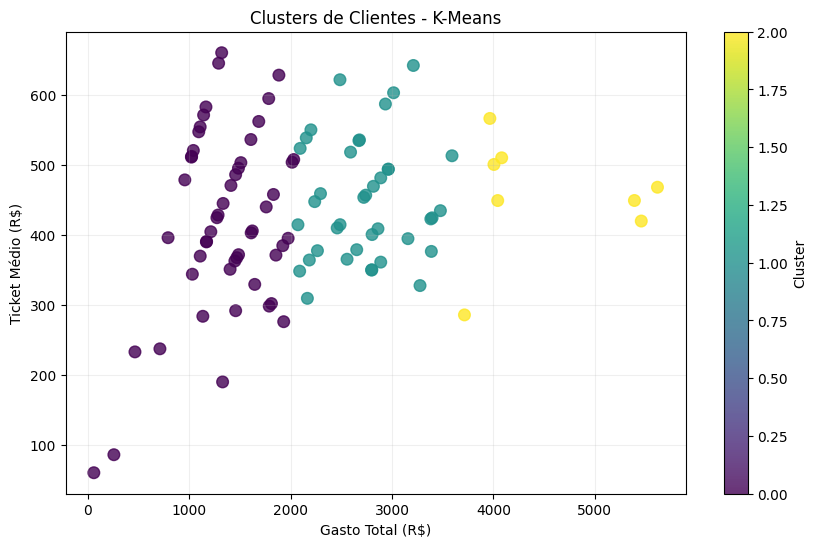

In [13]:
# ============================================================
# GRÁFICO DOS CLUSTERS
# ============================================================

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    cluster_data["gasto_total"],
    cluster_data["ticket_medio"],
    c=cluster_data["cluster"],
    s=70,
    alpha=0.8
)

plt.xlabel("Gasto Total (R$)")
plt.ylabel("Ticket Médio (R$)")
plt.title("Clusters de Clientes - K-Means")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.2)

plt.show()

In [14]:
# ============================================================
# 5. REGRESSÃO LINEAR - MACHINE LEARNING
# Previsão do gasto total com base em idade e renda
# ============================================================

# Une somente os clientes que possuem registros de gastos
base_regressao = clientes.merge(
    gastos,
    on="id_cliente",
    how="inner"
)

print("Quantidade de clientes na regressão:", len(base_regressao))

# Variáveis explicativas
X = base_regressao[["idade", "renda"]]

# Variável que queremos prever
y = base_regressao["gasto_total"]

# Separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Criação e treinamento da regressão
modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)

print("\n=== RESULTADOS DA REGRESSÃO LINEAR ===")

print("Coeficiente da idade:",
      modelo_lr.coef_[0])

print("Coeficiente da renda:",
      modelo_lr.coef_[1])

print("Intercepto:",
      modelo_lr.intercept_)

Quantidade de clientes na regressão: 98

=== RESULTADOS DA REGRESSÃO LINEAR ===
Coeficiente da idade: -6.801382890828222
Coeficiente da renda: -0.002244543420921779
Intercepto: 2448.4490187647943


In [15]:
# ============================================================
# AVALIAÇÃO DA REGRESSÃO
# ============================================================

from sklearn.metrics import r2_score, mean_absolute_error

# Faz previsões com a base de teste
y_pred = modelo_lr.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("=== AVALIAÇÃO DO MODELO ===")

print("R²:", round(r2, 4))

print(
    "Erro Médio Absoluto (MAE): R$",
    round(mae, 2)
)

=== AVALIAÇÃO DO MODELO ===
R²: -0.0274
Erro Médio Absoluto (MAE): R$ 795.1


In [16]:
# ============================================================
# COMPARAÇÃO DA IMPORTÂNCIA DAS VARIÁVEIS
# COEFICIENTES PADRONIZADOS
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modelo_padronizado = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

modelo_padronizado.fit(
    X_train,
    y_train
)

coef_padronizados = (
    modelo_padronizado
    .named_steps["linearregression"]
    .coef_
)

print("=== COEFICIENTES PADRONIZADOS ===")

print(
    "Idade:",
    round(coef_padronizados[0], 4)
)

print(
    "Renda:",
    round(coef_padronizados[1], 4)
)

if abs(coef_padronizados[0]) > abs(coef_padronizados[1]):
    print("\nVariável com maior contribuição: IDADE")
else:
    print("\nVariável com maior contribuição: RENDA")

=== COEFICIENTES PADRONIZADOS ===
Idade: -100.1813
Renda: -8.6034

Variável com maior contribuição: IDADE


In [17]:
# ============================================================
# 6. DEEP LEARNING - PREPARAÇÃO DOS DADOS
# ============================================================

from sklearn.preprocessing import StandardScaler

# Criamos um normalizador exclusivo para a rede neural
scaler_nn = StandardScaler()

# Ajusta somente com os dados de treino
X_train_nn = scaler_nn.fit_transform(X_train)

# Aplica a mesma transformação aos dados de teste
X_test_nn = scaler_nn.transform(X_test)

print("Formato dos dados de treino:", X_train_nn.shape)
print("Formato dos dados de teste:", X_test_nn.shape)

Formato dos dados de treino: (78, 2)
Formato dos dados de teste: (20, 2)


In [18]:
# ============================================================
# 6. MINI REDE NEURAL - DEEP LEARNING
# Previsão do gasto total
# ============================================================

# Semente para ajudar na reprodutibilidade
tf.random.set_seed(42)

modelo_nn = keras.Sequential([

    # Primeira camada oculta
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(
        16,
        activation="relu"
    ),

    # Segunda camada oculta
    keras.layers.Dense(
        8,
        activation="relu"
    ),

    # Camada de saída
    keras.layers.Dense(1)
])

# Configuração do treinamento
modelo_nn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Mostra a arquitetura da rede
modelo_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# TREINAMENTO DA REDE NEURAL
# ============================================================

historico = modelo_nn.fit(
    X_train_nn,
    y_train,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

print("Rede Neural treinada com sucesso!")

print(
    "Loss final:",
    round(historico.history["loss"][-1], 2)
)

print(
    "MAE final:",
    round(historico.history["mae"][-1], 2)
)

Rede Neural treinada com sucesso!
Loss final: 5492958.5
MAE final: 2107.32


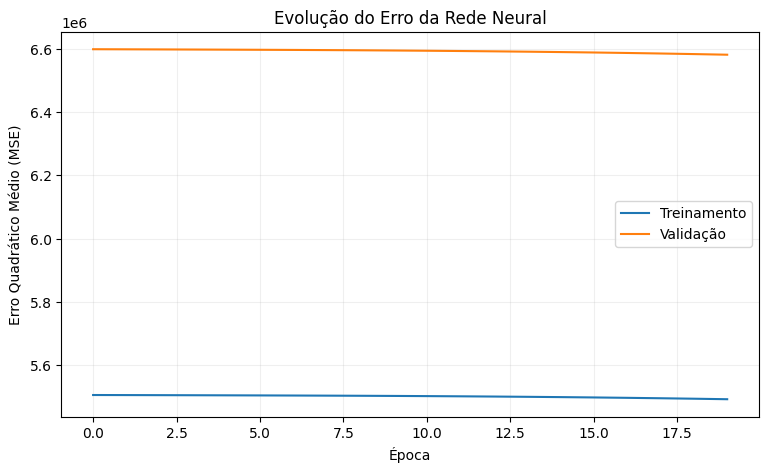

In [20]:
# ============================================================
# GRÁFICO DO TREINAMENTO
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    historico.history["loss"],
    label="Treinamento"
)

plt.plot(
    historico.history["val_loss"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Erro Quadrático Médio (MSE)")
plt.title("Evolução do Erro da Rede Neural")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [21]:
# ============================================================
# 7. MONGODB SIMULADO + LGPD
# ============================================================

# Faz uma cópia dos dados dos clusters
documento_mongo = cluster_data.copy()

# Cria um identificador alternativo para o cliente
documento_mongo["id_cliente_anon"] = (
    documento_mongo["id_cliente"]
    .apply(lambda x: f"user_{x}")
)

# Remove o identificador original
documento_mongo = documento_mongo.drop(
    columns=["id_cliente"]
)

# Reorganiza as colunas
documento_mongo = documento_mongo[
    [
        "id_cliente_anon",
        "gasto_total",
        "num_compras",
        "ticket_medio",
        "cluster"
    ]
]

print("=== DOCUMENTO MONGODB COM IDENTIFICAÇÃO REMOVIDA ===")

display(documento_mongo.head(10))

=== DOCUMENTO MONGODB COM IDENTIFICAÇÃO REMOVIDA ===


,id_cliente_anon,gasto_total,num_compras,ticket_medio,cluster
0,user_1,2557.30,7,365.328571,1
1,user_2,1784.81,3,594.936667,0
2,user_3,1165.86,2,582.930000,0
3,user_4,1458.53,3,486.176667,0
4,user_5,2031.20,4,507.800000,0
5,user_6,2935.70,5,587.140000,1
6,user_7,1831.48,4,457.870000,0
7,user_8,2801.97,8,350.246250,1
8,user_9,3016.13,5,603.226000,1
9,user_10,2200.95,4,550.237500,1


In [22]:
# ============================================================
# EXPORTAÇÃO PARA JSON - SIMULAÇÃO DE DOCUMENTO MONGODB
# ============================================================

documento_mongo.to_json(
    "clientes_clusters_mongo.json",
    orient="records",
    indent=4,
    force_ascii=False
)

print("Arquivo clientes_clusters_mongo.json gerado com sucesso!")

Arquivo clientes_clusters_mongo.json gerado com sucesso!


In [23]:
# ============================================================
# EXEMPLO DE DOCUMENTO NoSQL
# ============================================================

import json

primeiro_documento = documento_mongo.iloc[0].to_dict()

print("=== EXEMPLO DE DOCUMENTO MONGODB ===")
print(
    json.dumps(
        primeiro_documento,
        indent=4,
        ensure_ascii=False
    )
)

=== EXEMPLO DE DOCUMENTO MONGODB ===
{
    "id_cliente_anon": "user_1",
    "gasto_total": 2557.3,
    "num_compras": 7,
    "ticket_medio": 365.3285714285715,
    "cluster": 1
}
